In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (8,8)

In [7]:
from google.colab import files

uploaded = files.upload()

Saving Hand_0011669.jpg to Hand_0011669.jpg


(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

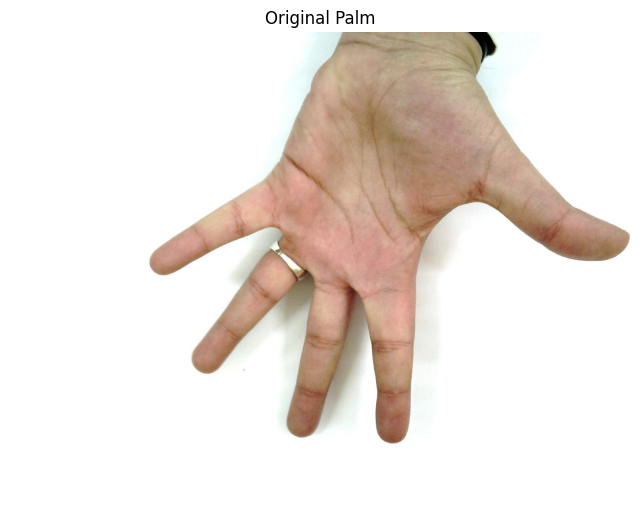

In [8]:
image_name = next(iter(uploaded.keys()))

img = cv2.imread(image_name)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Palm")
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

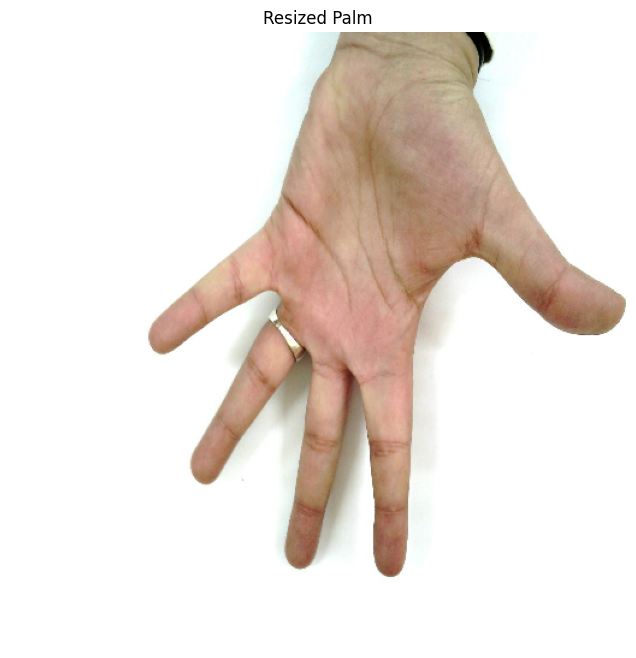

In [9]:
img = cv2.resize(img, (512,512))

plt.imshow(img)
plt.title("Resized Palm")
plt.axis("off")

(np.float64(-0.5), np.float64(326.5), np.float64(383.5), np.float64(-0.5))

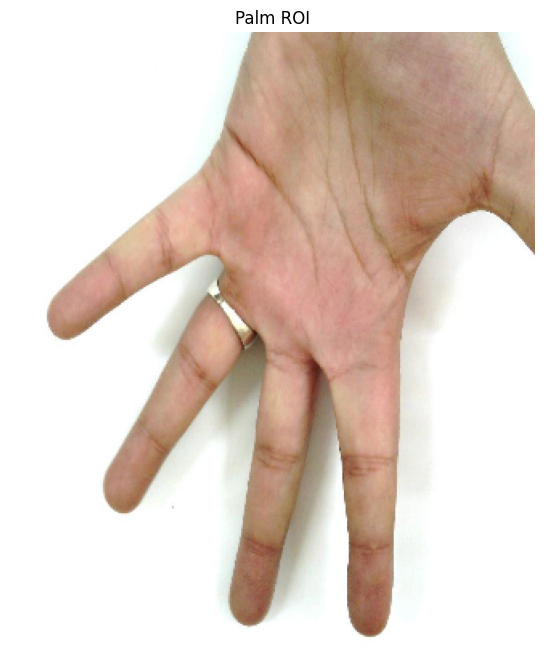

In [10]:
h, w = img.shape[:2]

x1 = int(0.18*w)
x2 = int(0.82*w)

y1 = int(0.15*h)
y2 = int(0.90*h)

roi = img[y1:y2, x1:x2]

plt.imshow(roi)
plt.title("Palm ROI")
plt.axis("off")

(np.float64(-0.5), np.float64(326.5), np.float64(383.5), np.float64(-0.5))

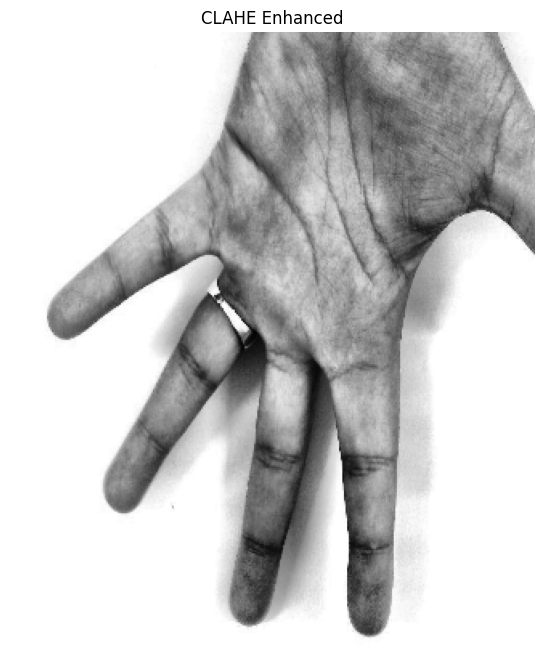

In [11]:
gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(
    clipLimit=2.5,
    tileGridSize=(8,8)
)

gray = clahe.apply(gray)

plt.figure(figsize=(8,8))
plt.imshow(gray, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

(np.float64(-0.5), np.float64(326.5), np.float64(383.5), np.float64(-0.5))

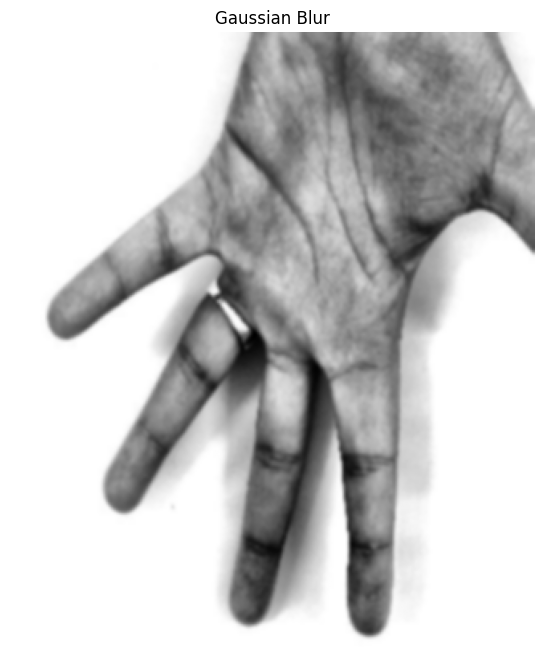

In [12]:
blur = cv2.GaussianBlur(
    gray,
    (5,5),
    0
)

plt.figure(figsize=(8,8))
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

(np.float64(-0.5), np.float64(326.5), np.float64(383.5), np.float64(-0.5))

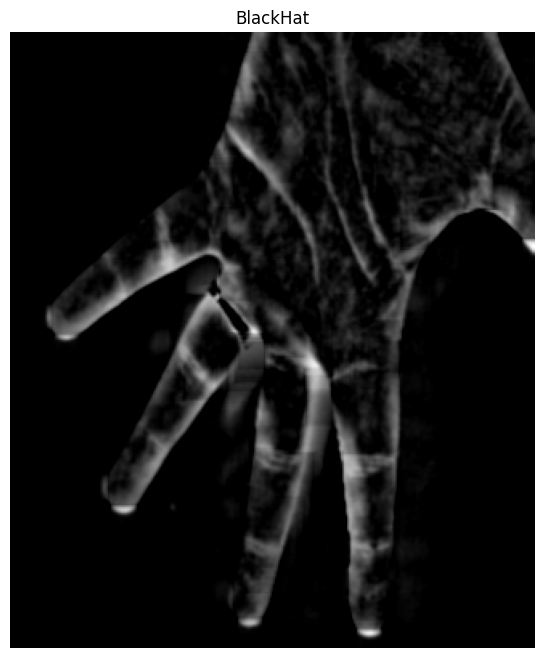

In [13]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (17,17)
)

blackhat = cv2.morphologyEx(
    blur,
    cv2.MORPH_BLACKHAT,
    kernel
)

plt.figure(figsize=(8,8))
plt.imshow(blackhat, cmap="gray")
plt.title("BlackHat")
plt.axis("off")

In [31]:
# Clone the GitHub repository
!git clone https://github.com/yeonsumia/palmistry.git

# Add the cloned 'code' directory to Python's path so we can import its modules
import sys

# Remove existing palmistry path if it was added incorrectly
if './palmistry' in sys.path:
    sys.path.remove('./palmistry')
if './palmistry/code' not in sys.path:
    sys.path.append('./palmistry/code') # Corrected path to include the 'code' subdirectory

fatal: destination path 'palmistry' already exists and is not an empty directory.


In [32]:
# Install PyTorch if not already installed. The GitHub repository uses PyTorch.
try:
    import torch
except ImportError:
    print("PyTorch not found, installing...")
    # Install PyTorch with CUDA 11.8 (common for Colab T4 GPUs). Adjust if your runtime has a different CUDA version.
    !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cpu


In [39]:
from torchvision import transforms

# Try to import the model architecture from the cloned repository
try:
    from model import (
        UNet,  # Corrected import statement as 'palmistry/code' is now on sys.path
    )
    print("Successfully imported UNet model architecture.")
except ImportError as e:
    print(f"Could not import UNet from model: {e}")
    print("Please ensure 'model.py' is correctly located within './palmistry/code'.")
    print("And verify the file exists and is not corrupted.")

# Instantiate the model
# Based on the error messages, the checkpoint expects 3 input channels (RGB) and 1 output channel (combined mask)
model = UNet(n_channels=3, n_classes=1) # Corrected to match checkpoint's input/output channels

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Model instantiated and moved to device: {device}")

# --- Load pre-trained weights ---
model_weights_path = './palmistry/code/checkpoint/checkpoint_aug_epoch70.pth'

try:
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.eval() # Set the model to evaluation mode
    print(f"Successfully loaded model weights from: {model_weights_path}")
except FileNotFoundError:
    print(f"Error: Model weights file not found at {model_weights_path}.")
    print("Please check the path or ensure the correct checkpoint file exists.")
except Exception as e:
    print(f"An error occurred while loading model weights: {e}")
    print("This might be due to incorrect model architecture parameters, corrupted weights, or compatibility issues.")

print("Model setup complete. Ready for inference.")

Successfully imported UNet model architecture.
Model instantiated and moved to device: cpu
Successfully loaded model weights from: ./palmistry/code/checkpoint/checkpoint_aug_epoch70.pth
Model setup complete. Ready for inference.


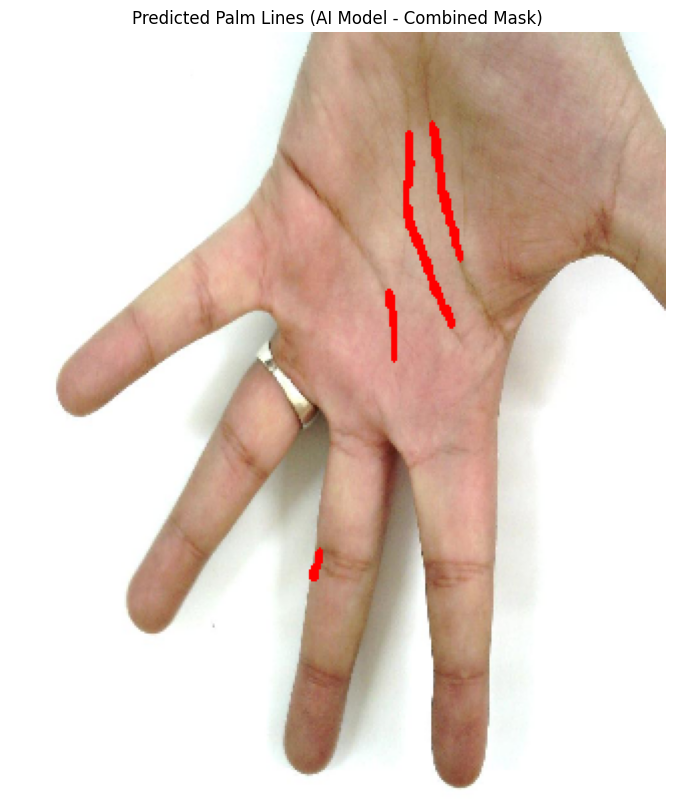

In [41]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Preprocess the ROI image for the model
# The model expects RGB input (3 channels), so no Grayscale conversion here.
roi_pil = Image.fromarray(roi)

# Define transformations for inference (must match training transformations)
# Model expects RGB 3-channel input and 256x256 size.
inference_transform = transforms.Compose([
    transforms.Resize((256, 256)), # Model's expected input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalization for 3 channels
])

# Apply transformations and add a batch dimension
input_tensor = inference_transform(roi_pil).unsqueeze(0).to(device)

# Perform inference
model.eval() # Ensure model is in evaluation mode
with torch.no_grad():
    output = model(input_tensor)

# Process output (assuming single class output, so output shape will be [1, 1, H, W])
# Apply sigmoid and remove batch and channel dimensions to get a [H, W] mask.
threshold = 0.5 # Adjust threshold as needed
predicted_mask = (torch.sigmoid(output).squeeze().cpu().numpy() > threshold).astype(np.uint8)

# Resize the predicted mask back to original ROI size for visualization
mask_resized = cv2.resize(predicted_mask, (roi.shape[1], roi.shape[0]), interpolation=cv2.INTER_NEAREST)

# Create an image to draw the detected lines on
output_display_image = roi.copy()

# Find contours from the resized mask
contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Define a single color for the combined palm lines (e.g., yellow)
line_color_bgr = (255, 0, 0) # Blue in BGR format (OpenCV uses BGR)

# Draw contours on the output_display_image
if contours:
    cv2.drawContours(output_display_image, contours, -1, line_color_bgr, 2) # Draw with thickness 2

# Display the result
plt.figure(figsize=(10, 10))
plt.imshow(output_display_image)
plt.title("Predicted Palm Lines (AI Model - Combined Mask)")
plt.axis('off')
plt.show()

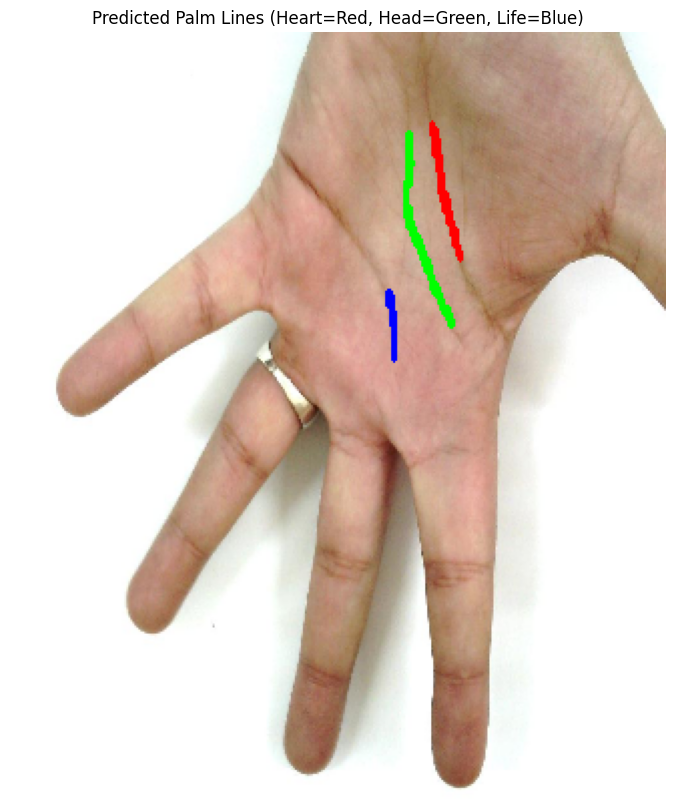

In [45]:
contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter out tiny noise contours
valid_contours = [c for c in contours if cv2.contourArea(c) > 15]

# Collect stats for each contour: topmost y, centroid x/y
stats = []
for cnt in valid_contours:
    x, y, cw, ch = cv2.boundingRect(cnt)
    M = cv2.moments(cnt)
    cx = M['m10'] / M['m00'] if M['m00'] != 0 else x + cw / 2
    cy = M['m10'] / M['m00'] if M['m00'] != 0 else y + ch / 2
    cy = M['m01'] / M['m00'] if M['m00'] != 0 else y + ch / 2
    topmost_y = y  # smallest y = closest to fingers
    stats.append({'cnt': cnt, 'cx': cx, 'cy': cy, 'top_y': topmost_y})

output_display_image = roi.copy()

if len(stats) > 0:
    # Heart line = the contour closest to the fingers (smallest top_y)
    heart = min(stats, key=lambda s: s['top_y'])
    remaining = [s for s in stats if s is not heart]

    # Life line = closest to thumb side.
    # IMPORTANT: check your ROI — if thumb is on the LEFT, use min(cx).
    # If thumb is on the RIGHT, use max(cx) instead.
    life = min(remaining, key=lambda s: s['cx']) if remaining else None
    remaining = [s for s in remaining if s is not life]

    # Head line = whatever is left (usually the longest/middle one)
    head_list = remaining

    # Draw
    cv2.drawContours(output_display_image, [heart['cnt']], -1, (255, 0, 0), 2)   # Red - Heart
    for h in head_list:
        cv2.drawContours(output_display_image, [h['cnt']], -1, (0, 255, 0), 2)   # Green - Head
    if life is not None:
        cv2.drawContours(output_display_image, [life['cnt']], -1, (0, 0, 255), 2)  # Blue - Life

plt.figure(figsize=(10, 10))
plt.imshow(output_display_image)
plt.title("Predicted Palm Lines (Heart=Red, Head=Green, Life=Blue)")
plt.axis('off')
plt.show()

Extract Features


In [46]:
import cv2
import numpy as np


def extract_features(line, name):

    if line is None:
        return {
            "Line": name,
            "Length": 0,
            "Area": 0,
            "Angle": 0,
            "Center_X": 0,
            "Center_Y": 0
        }

    cnt = line["cnt"]

    length = cv2.arcLength(cnt, False)
    area = cv2.contourArea(cnt)

    x, y, w, h = cv2.boundingRect(cnt)

    M = cv2.moments(cnt)

    if M["m00"] != 0:
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
    else:
        cx = x + w/2
        cy = y + h/2

    angle = np.degrees(np.arctan2(h, w))

    return {
        "Line": name,
        "Length": round(length,2),
        "Area": round(area,2),
        "Angle": round(angle,2),
        "Center_X": round(cx,2),
        "Center_Y": round(cy,2)
    }

rows = []

rows.append(extract_features(heart, "Heart"))

if len(head_list) > 0:
    rows.append(extract_features({"cnt": head_list[0]["cnt"]}, "Head"))
else:
    rows.append(extract_features(None, "Head"))

rows.append(extract_features(life, "Life"))

df = pd.DataFrame(rows)

df

,Line,Length,Area,Angle,Center_X,Center_Y
0,Heart,149.11,77.0,77.74,215.46,75.70
1,Head,219.57,104.0,76.10,204.16,99.25
2,Life,70.66,18.0,83.48,189.44,136.25


In [47]:
df.to_csv("Palm_Line_Features.csv", index=False)

print("Palm_Line_Features.csv saved successfully.")

Palm_Line_Features.csv saved successfully.


Interpretation


In [48]:
def interpret(length):

    if length >= 170:
        return "Long"

    elif length >= 100:
        return "Medium"

    else:
        return "Short"

df["Interpretation"] = df["Length"].apply(interpret)

df

,Line,Length,Area,Angle,Center_X,Center_Y,Interpretation
0,Heart,149.11,77.0,77.74,215.46,75.70,Medium
1,Head,219.57,104.0,76.10,204.16,99.25,Long
2,Life,70.66,18.0,83.48,189.44,136.25,Short


final report


In [49]:
print("="*50)
print(" AI PALM ANALYSIS REPORT ")
print("="*50)

for _, row in df.iterrows():
    print(f"\n{row['Line']} Line")
    print(f"Length : {row['Length']}")
    print(f"Angle : {row['Angle']}")
    print(f"Interpretation : {row['Interpretation']}")

 AI PALM ANALYSIS REPORT 

Heart Line
Length : 149.11
Angle : 77.74
Interpretation : Medium

Head Line
Length : 219.57
Angle : 76.1
Interpretation : Long

Life Line
Length : 70.66
Angle : 83.48
Interpretation : Short
